<a href="https://colab.research.google.com/github/Poojan0922/Classification_Project/blob/main/predicting_stars_galaxies_quasars_with_ml_model_BoxPlots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Box-Plots of evaluation metrics (per class label)


## Importing generic libraries:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
%matplotlib inline

## Installing machine learning libraries:

In [ ]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
conda install lightgbm

Retrieving notices: ...working... done
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## Importing all the Machine learning model libraries:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.svm import SVC
from sklearn.svm import NuSVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

## Data Preparation and analysis:

In [ ]:
data = pd.read_csv("Skyserver_SQL2_27_2018 6_51_39 PM.csv")
data.drop(['objid','specobjid'], axis=1, inplace=True)

In [ ]:
g = 0
s = 0
q = 0
for i in range(len(data["class"])):
    if data["class"][i] == "GALAXY":
        g = g+1
    elif data["class"][i] == "STAR":
        s = s+ 1
    else:
        q = q+1
print("Number of galaxies: ",g)
print("Number of quasars: ",q)
print("Number of stars: ",s)

Number of galaxies:  4998
Number of quasars:  850
Number of stars:  4152


In [ ]:
le = LabelEncoder().fit(data['class'])
data['class'] = le.transform(data['class'])

In [ ]:
X = data.drop('class', axis=1)
y = data['class']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=True , with_mean= True , with_std = True)
X= scaler.fit_transform(X)

Class labels:

In [ ]:
target = ["Galaxies", "Quasars", "Stars"]

## Function to train and test each model and report the necessary evaluation metric values:

In [ ]:
def metric(model, train_X, train_Y, test_X, test_Y):
    model.fit(train_X, train_Y)
    pred = model.predict(test_X)
    cl = classification_report(test_Y, pred, target_names = target, output_dict = True)
    acc = cl['accuracy']
    Gprec, Qprec, Sprec = cl['Galaxies']['precision'], cl['Quasars']['precision'], cl['Stars']['precision']
    Grec, Qrec, Srec = cl['Galaxies']['recall'], cl['Quasars']['recall'], cl['Stars']['recall']
    Gf1, Qf1, Sf1 = cl['Galaxies']['f1-score'], cl['Quasars']['f1-score'], cl['Stars']['f1-score']
    return acc, Gprec, Grec, Gf1, Qprec, Qrec, Qf1, Sprec, Srec, Sf1

## 1st Batch:

In [ ]:
result1 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models1 = ["DTC", "LR", "KNN", "NC", "RBFSVM", "PSVM", "Nu-SVM", "LSVM2", "LSVM1", "PA"]
for i in range(200):
    DTModel = DecisionTreeClassifier()
    LRModel = LogisticRegression(max_iter = 1000)
    NeNeModel = KNeighborsClassifier(n_neighbors=5, algorithm = 'ball_tree')
    NCModel = NearestCentroid()
    SVCModel = SVC(probability = True)
    SVCPModel = SVC(kernel = 'poly', probability = True)
    NSVCModel = NuSVC(nu = 0.2, probability = True)
    LSVCModel = LinearSVC(max_iter = 100000)
    LSVC1Model = LinearSVC(penalty = 'l1', loss = 'squared_hinge', max_iter = 100000, dual = False)
    PAModel = PassiveAggressiveClassifier()
    lis = [DTModel, LRModel, NeNeModel, NCModel, SVCModel, SVCPModel, NSVCModel, LSVCModel, LSVC1Model, PAModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models1, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result1["Model"].append(m)
        result1["Accuracy"].append(a)
        result1["Galaxies Precision"].append(gp)
        result1["Galaxies Recall"].append(gr)
        result1["Galaxies F1"].append(gf)
        result1["Quasars Precision"].append(qp)
        result1["Quasars Recall"].append(qr)
        result1["Quasars F1"].append(qf)
        result1["Stars Precision"].append(sp)
        result1["Stars Recall"].append(sr)
        result1["Stars F1"].append(sf)

In [ ]:
Data1 = pd.DataFrame(result1)
print(Data1)

       Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0        DTC    0.9830            0.983952         0.981982     0.982966   
1         LR    0.9750            0.982724         0.967968     0.975290   
2        KNN    0.8990            0.876048         0.940941     0.907336   
3         NC    0.8730            0.824873         0.975976     0.894085   
4     RBFSVM    0.9575            0.952616         0.965966     0.959245   
...      ...       ...                 ...              ...          ...   
1995    PSVM    0.9215            0.897059         0.957802     0.926436   
1996  Nu-SVM    0.9485            0.943961         0.958783     0.951315   
1997   LSVM2    0.9725            0.979146         0.967615     0.973346   
1998   LSVM1    0.9810            0.984221         0.979392     0.981800   
1999      PA    0.9500            0.954545         0.947988     0.951256   

      Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0              

In [ ]:
Data1.to_csv("NBox1.csv", index = False)

## 2nd Batch:

In [ ]:
result2 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models2 = ["KNNKD", "KNNB"]
for i in range(200):
    NeNeKDModel = KNeighborsClassifier(n_neighbors=5, algorithm = 'kd_tree')
    NeNeBModel = KNeighborsClassifier(n_neighbors=5, algorithm = 'brute')
    lis = [NeNeKDModel, NeNeBModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models2, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result2["Model"].append(m)
        result2["Accuracy"].append(a)
        result2["Galaxies Precision"].append(gp)
        result2["Galaxies Recall"].append(gr)
        result2["Galaxies F1"].append(gf)
        result2["Quasars Precision"].append(qp)
        result2["Quasars Recall"].append(qr)
        result2["Quasars F1"].append(qf)
        result2["Stars Precision"].append(sp)
        result2["Stars Recall"].append(sr)
        result2["Stars F1"].append(sf)

In [ ]:
Data2 = pd.DataFrame(result2)
print(Data2)

     Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0    KNNKD    0.8990            0.876048         0.940941     0.907336   
1     KNNB    0.8990            0.876048         0.940941     0.907336   
2    KNNKD    0.9120            0.893939         0.944945     0.918735   
3     KNNB    0.9120            0.893939         0.944945     0.918735   
4    KNNKD    0.8960            0.861266         0.951646     0.904203   
..     ...       ...                 ...              ...          ...   
395   KNNB    0.9075            0.888785         0.945328     0.916185   
396  KNNKD    0.9015            0.868371         0.945361     0.905232   
397   KNNB    0.9015            0.868371         0.945361     0.905232   
398  KNNKD    0.9105            0.896359         0.942100     0.918660   
399   KNNB    0.9105            0.896359         0.942100     0.918660   

     Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0             0.966887        0.820225  

In [ ]:
Data2.to_csv("NBox2.csv", index = False)

## 3rd Batch:

In [ ]:
result3 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models3 = ["RF", "RFE", "GNB", "GBC", "HGBC", "LGBC", "XGBC", "ABC", "CBC", "SGD2"]
for i in range(200):
    RFModel = RandomForestClassifier()
    RFEModel = RandomForestClassifier(criterion = 'entropy')
    GNBModel = GaussianNB()
    GBCModel = GradientBoostingClassifier()
    HGBCModel = HistGradientBoostingClassifier()
    LGBModel = LGBMClassifier()
    XGBModel = xgb.XGBClassifier()
    ABCModel = AdaBoostClassifier()
    CBModel = CatBoostClassifier(silent = True)
    SGDModel = SGDClassifier()
    lis = [RFModel, RFEModel, GNBModel, GBCModel, HGBCModel, LGBModel, XGBModel, ABCModel, CBModel, SGDModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models3, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result3["Model"].append(m)
        result3["Accuracy"].append(a)
        result3["Galaxies Precision"].append(gp)
        result3["Galaxies Recall"].append(gr)
        result3["Galaxies F1"].append(gf)
        result3["Quasars Precision"].append(qp)
        result3["Quasars Recall"].append(qr)
        result3["Quasars F1"].append(qf)
        result3["Stars Precision"].append(sp)
        result3["Stars Recall"].append(sr)
        result3["Stars F1"].append(sf)

/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

In [ ]:
Data3 = pd.DataFrame(result3)
print(Data3)

     Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0     SGD1    0.9835            0.978218         0.988989     0.983574   
1     SGDE    0.9705            0.971888         0.968969     0.970426   
2      LDA    0.9055            0.865229         0.963964     0.911932   
3      QDA    0.7210            0.930189         0.493493     0.644866   
4       BC    0.9890            0.987039         0.990991     0.989011   
...    ...       ...                 ...              ...          ...   
1995   ETC    0.9820            0.983301         0.982336     0.982818   
1996   CCV    0.9715            0.977205         0.967615     0.972387   
1997    RC    0.9135            0.894542         0.948970     0.920952   
1998   RCV    0.9120            0.893519         0.947007     0.919485   
1999   MLP    0.9835            0.992032         0.977429     0.984676   

      Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0              0.976471        0.932584

In [ ]:
Data3.to_csv("NBox3.csv", index = False)

## 4th Batch:

In [ ]:
result4 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models4 = ["SGD1", "SGDE", "LDA", "QDA", "BC", "ETC", "CCV", "RC", "RCV", "MLP"]
for i in range(200):
    SGD1Model = SGDClassifier(penalty = 'l1')
    SGDEModel = SGDClassifier(penalty = 'elasticnet')
    LDAModel = LinearDiscriminantAnalysis()
    QDAModel = QuadraticDiscriminantAnalysis()
    BModel = BaggingClassifier()
    ETModel = ExtraTreesClassifier()
    LSVCModel = LinearSVC(max_iter = 10000)
    CCVModel = CalibratedClassifierCV(LSVCModel)
    RModel = RidgeClassifier()
    RCVModel = RidgeClassifierCV()
    MLPModel = MLPClassifier(max_iter = 1000)
    lis = [SGD1Model, SGDEModel, LDAModel, QDAModel, BModel, ETModel, CCVModel, RModel, RCVModel, MLPModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models4, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result4["Model"].append(m)
        result4["Accuracy"].append(a)
        result4["Galaxies Precision"].append(gp)
        result4["Galaxies Recall"].append(gr)
        result4["Galaxies F1"].append(gf)
        result4["Quasars Precision"].append(qp)
        result4["Quasars Recall"].append(qr)
        result4["Quasars F1"].append(qf)
        result4["Stars Precision"].append(sp)
        result4["Stars Recall"].append(sr)
        result4["Stars F1"].append(sf)

In [ ]:
Data4 = pd.DataFrame(result4)
print(Data4)

     Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0     SGD1    0.9860            0.980218         0.991992     0.986070   
1     SGDE    0.9690            0.969910         0.967968     0.968938   
2      LDA    0.9055            0.865229         0.963964     0.911932   
3      QDA    0.7210            0.930189         0.493493     0.644866   
4       BC    0.9915            0.987103         0.995996     0.991530   
...    ...       ...                 ...              ...          ...   
1995   ETC    0.9800            0.984205         0.978410     0.981299   
1996   CCV    0.9715            0.977205         0.967615     0.972387   
1997    RC    0.9135            0.894542         0.948970     0.920952   
1998   RCV    0.9120            0.893519         0.947007     0.919485   
1999   MLP    0.9850            0.993028         0.978410     0.985665   

      Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0              0.982143        0.926966

In [ ]:
Data4.to_csv("NBox4.csv", index = False)

## 5th Batch:

In [ ]:
result5 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models5 = ["SV"]
for i in range(200):
    QDAModel = QuadraticDiscriminantAnalysis()
    MLPModel = MLPClassifier(max_iter = 1000)
    ETModel = ExtraTreesClassifier()
    BModel = BaggingClassifier()
    XGBModel = xgb.XGBClassifier()
    GNBModel = GaussianNB()
    DTModel = DecisionTreeClassifier()
    SVCModel = SVC(probability = True)
    NSVCModel = NuSVC(nu = 0.2, probability = True)
    SVCPModel = SVC(kernel = 'poly', probability = True)
    RFModel = RandomForestClassifier()

    Ensemble = [('QDA', QDAModel), ('Nu-SVM', NSVCModel), ('RBFSVM', SVCModel), ('PSVM', SVCPModel), ('DT', DTModel), ('RF', RFModel), ('XGBC', XGBModel), ('BC', BModel), ('MLP', MLPModel), ('ETC', ETModel), ('GNB', GNBModel)]

    SVModel = VotingClassifier(estimators = Ensemble, voting = 'soft')

    lis = [SVModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models5, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result5["Model"].append(m)
        result5["Accuracy"].append(a)
        result5["Galaxies Precision"].append(gp)
        result5["Galaxies Recall"].append(gr)
        result5["Galaxies F1"].append(gf)
        result5["Quasars Precision"].append(qp)
        result5["Quasars Recall"].append(qr)
        result5["Quasars F1"].append(qf)
        result5["Stars Precision"].append(sp)
        result5["Stars Recall"].append(sr)
        result5["Stars F1"].append(sf)

/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/sakshamchandna/opt/anaconda3/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:878: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [ ]:
Data5 = pd.DataFrame(result5)
print(Data5)

In [ ]:
Data5.to_csv("NBox5.csv", index = False)

## 6th Batch:

In [ ]:
result6 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models6 = ["HV"]
for i in range(200):
    QDAModel = QuadraticDiscriminantAnalysis()
    MLPModel = MLPClassifier(max_iter = 1000)
    ETModel = ExtraTreesClassifier()
    BModel = BaggingClassifier()
    XGBModel = xgb.XGBClassifier()
    GNBModel = GaussianNB()
    DTModel = DecisionTreeClassifier()
    SVCModel = SVC(probability = True)
    NSVCModel = NuSVC(nu = 0.2, probability = True)
    SVCPModel = SVC(kernel = 'poly', probability = True)
    RFModel = RandomForestClassifier()

    Ensemble = [('QDA', QDAModel), ('Nu-SVM', NSVCModel), ('RBFSVM', SVCModel), ('PSVM', SVCPModel), ('DT', DTModel), ('RF', RFModel), ('XGBC', XGBModel), ('BC', BModel), ('MLP', MLPModel), ('ETC', ETModel), ('GNB', GNBModel)]

    HVModel = VotingClassifier(estimators = Ensemble, voting = 'hard')

    lis = [HVModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models6, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result6["Model"].append(m)
        result6["Accuracy"].append(a)
        result6["Galaxies Precision"].append(gp)
        result6["Galaxies Recall"].append(gr)
        result6["Galaxies F1"].append(gf)
        result6["Quasars Precision"].append(qp)
        result6["Quasars Recall"].append(qr)
        result6["Quasars F1"].append(qf)
        result6["Stars Precision"].append(sp)
        result6["Stars Recall"].append(sr)
        result6["Stars F1"].append(sf)

In [ ]:
Data6 = pd.DataFrame(result6)
print(Data6)

In [ ]:
Data6.to_csv("NBox6.csv", index = False)

## 7th Batch:

In [ ]:
result7 = {"Model":[], "Accuracy": [], "Galaxies Precision":[], "Galaxies Recall": [], "Galaxies F1": [], "Quasars Precision":[], "Quasars Recall": [], "Quasars F1": [], "Stars Precision":[], "Stars Recall": [], "Stars F1": []}
models7 = ["St"]
for i in range(200):
    SVCModel = SVC(probability = True)
    PAModel = PassiveAggressiveClassifier()
    LRModel = LogisticRegression(max_iter = 10000)
    NeNeModel = KNeighborsClassifier(n_neighbors=5, algorithm = 'ball_tree')
    STModel = StackingClassifier(estimators = [('RBFSVM', SVCModel), ('KNN', NeNeModel), ('PA', PAModel)], final_estimator = LRModel)
    lis = [STModel]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)

    for (m, mod) in zip(models4, lis):
        a, gp, gr, gf, qp, qr, qf, sp, sr, sf = metric(mod, X_train, y_train, X_test, y_test)
        result7["Model"].append(m)
        result7["Accuracy"].append(a)
        result7["Galaxies Precision"].append(gp)
        result7["Galaxies Recall"].append(gr)
        result7["Galaxies F1"].append(gf)
        result7["Quasars Precision"].append(qp)
        result7["Quasars Recall"].append(qr)
        result7["Quasars F1"].append(qf)
        result7["Stars Precision"].append(sp)
        result7["Stars Recall"].append(sr)
        result7["Stars F1"].append(sf)

In [ ]:
Data7 = pd.DataFrame(result7)
print(Data7)

     Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0    KNNKD    0.8990            0.876048         0.940941     0.907336   
1     KNNB    0.8990            0.876048         0.940941     0.907336   
2    KNNKD    0.9120            0.893939         0.944945     0.918735   
3     KNNB    0.9120            0.893939         0.944945     0.918735   
4    KNNKD    0.8960            0.861266         0.951646     0.904203   
..     ...       ...                 ...              ...          ...   
395   KNNB    0.9075            0.888785         0.945328     0.916185   
396  KNNKD    0.9015            0.868371         0.945361     0.905232   
397   KNNB    0.9015            0.868371         0.945361     0.905232   
398  KNNKD    0.9105            0.896359         0.942100     0.918660   
399   KNNB    0.9105            0.896359         0.942100     0.918660   

     Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0             0.966887        0.820225  

In [ ]:
Data7.to_csv("NBox7.csv", index = False)

# Plotting:

Get back individually saved data from all batches:

In [ ]:
Data1 = pd.read_csv("NBox1.csv")
Data2 = pd.read_csv("NBox2.csv")
Data3 = pd.read_csv("NBox3.csv")
Data4 = pd.read_csv("NBox4.csv")
Data5 = pd.read_csv("NBox5.csv")
Data6 = pd.read_csv("NBox6.csv")
Data7 = pd.read_csv("NBox7.csv")

In [ ]:
Data = Data1.append(Data2, ignore_index = True)
Data = Data.append(Data3, ignore_index = True)
Data = Data.append(Data4, ignore_index = True)
Data = Data.append(Data5, ignore_index = True)
Data = Data.append(Data6, ignore_index = True)
Data = Data.append(Data7, ignore_index = True)
print(Data)

       Model  Accuracy  Galaxies Precision  Galaxies Recall  Galaxies F1  \
0        DTC    0.9820            0.982949         0.980981     0.981964   
1         LR    0.9750            0.982724         0.967968     0.975290   
2        KNN    0.8990            0.876048         0.940941     0.907336   
3         NC    0.8730            0.824873         0.975976     0.894085   
4     RBFSVM    0.9575            0.952616         0.965966     0.959245   
...      ...       ...                 ...              ...          ...   
6995      St    0.9740            0.980229         0.966154     0.973140   
6996      St    0.9840            0.988212         0.980507     0.984344   
6997      St    0.9745            0.970443         0.979125     0.974765   
6998      St    0.9835            0.984488         0.981443     0.982963   
6999      St    0.9815            0.990030         0.974485     0.982196   

      Quasars Precision  Quasars Recall  Quasars F1  Stars Precision  \
0              

/var/folders/rn/twpr29l55kb_g5c9_gtvfwj40000gn/T/ipykernel_45305/1448360029.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  Data = Data1.append(Data5, ignore_index = True)
/var/folders/rn/twpr29l55kb_g5c9_gtvfwj40000gn/T/ipykernel_45305/1448360029.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  Data = Data.append(Data2, ignore_index = True)
/var/folders/rn/twpr29l55kb_g5c9_gtvfwj40000gn/T/ipykernel_45305/1448360029.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  Data = Data.append(Data3, ignore_index = True)
/var/folders/rn/twpr29l55kb_g5c9_gtvfwj40000gn/T/ipykernel_45305/1448360029.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat i

### Accuracy Box-Plot:

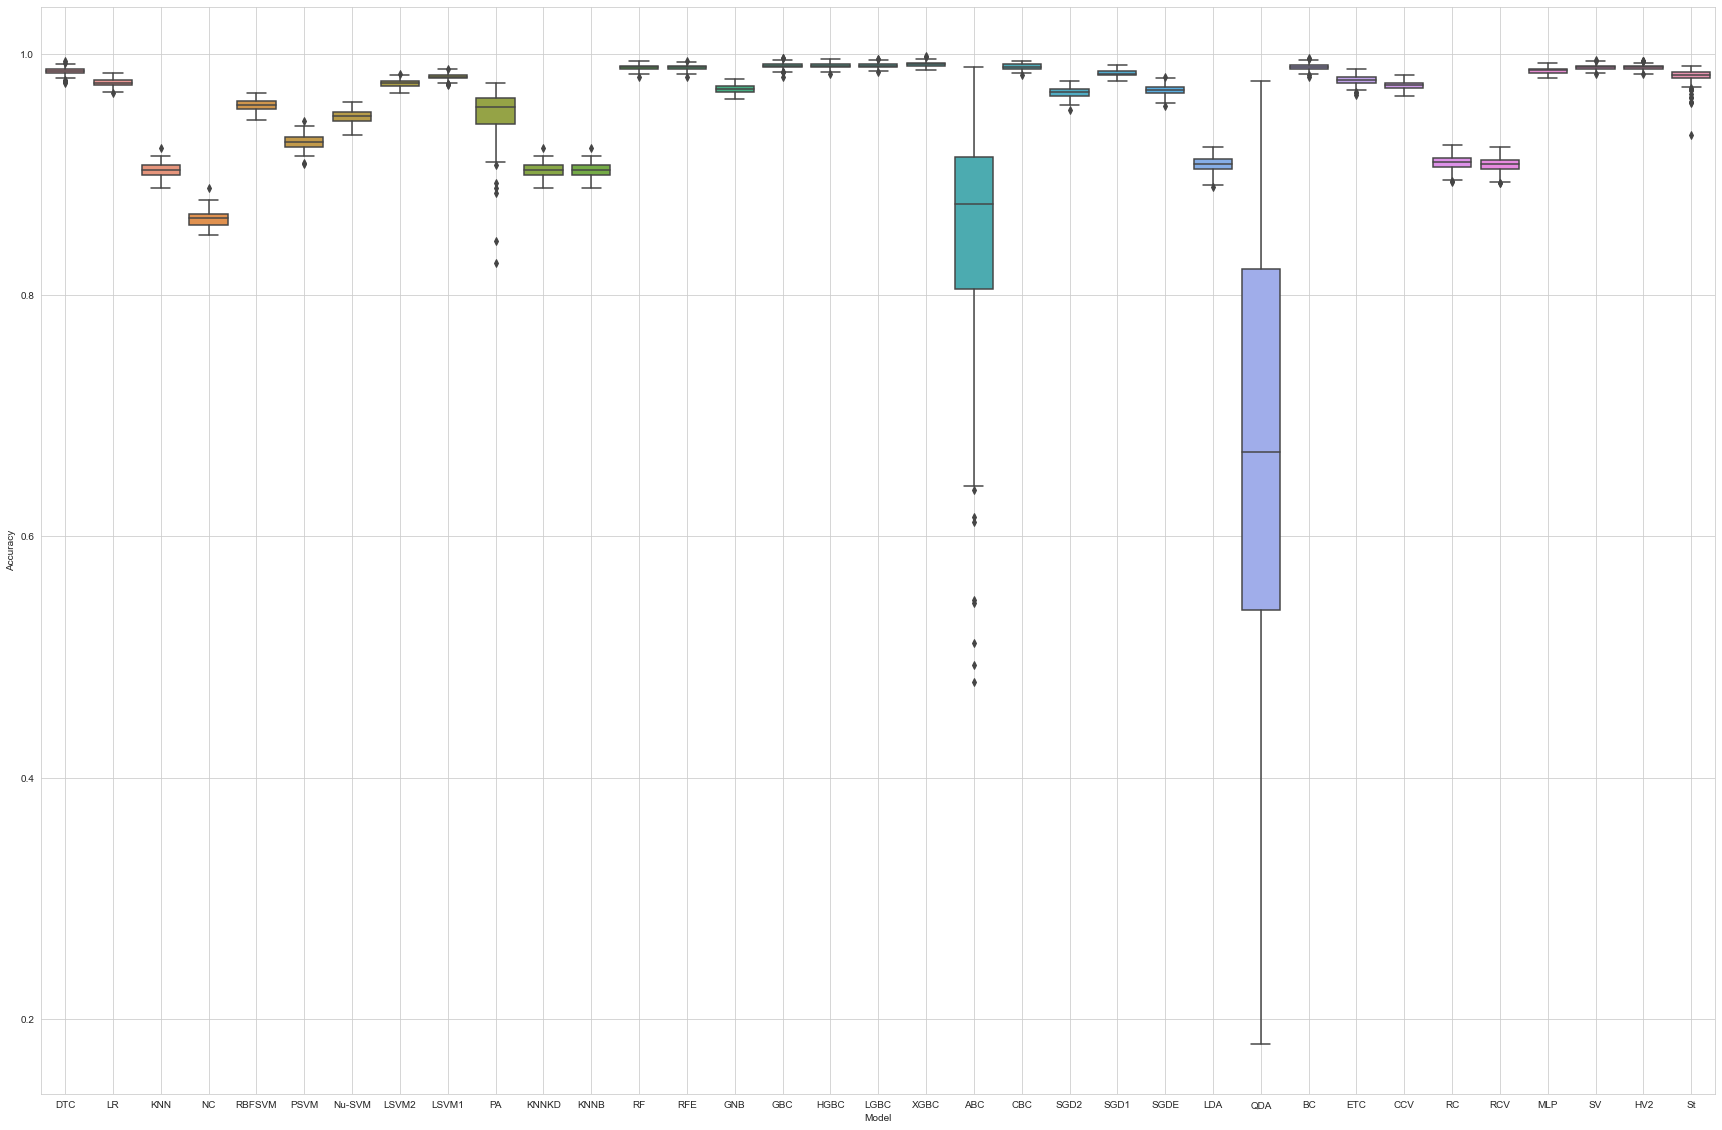

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style("whitegrid")
sns.boxplot(data = Data, x = "Model", y = "Accuracy")
plt.grid(visible=True)
plt.savefig("Accuracy.png")
plt.show()

### Galaxies Precision Box-Plot:

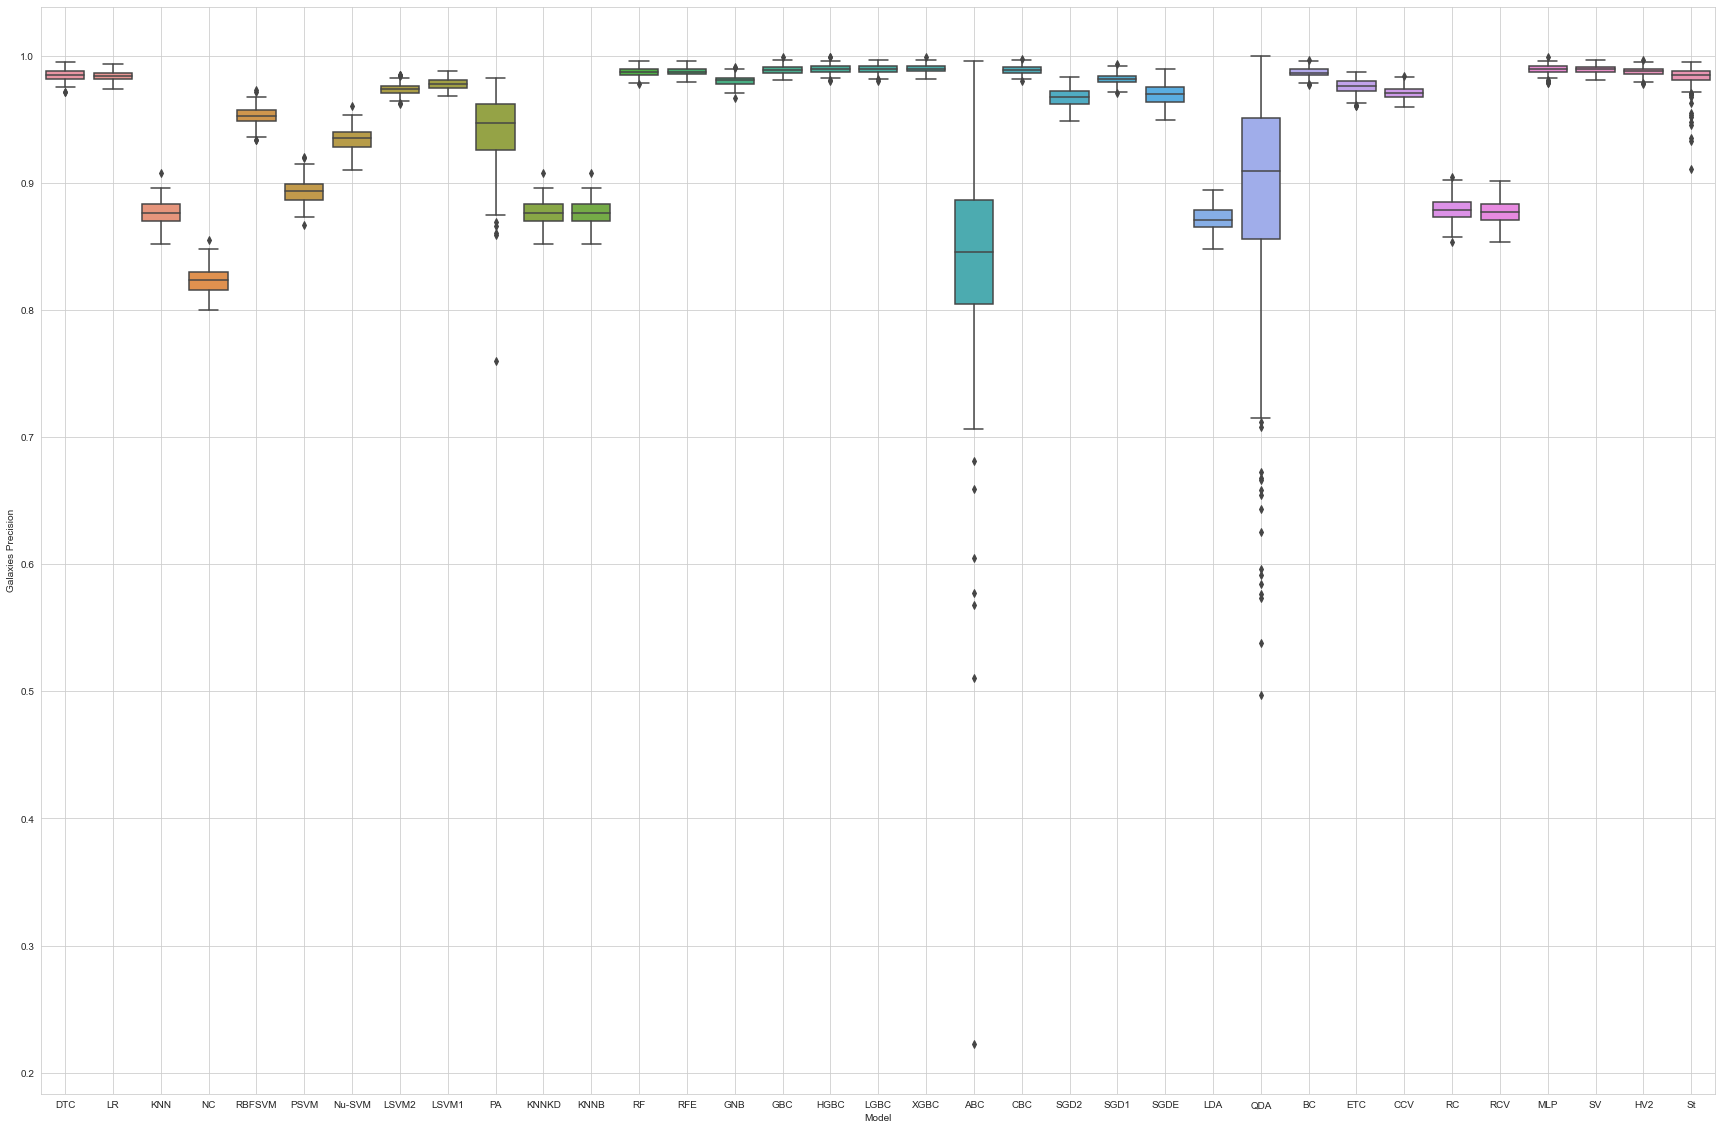

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Galaxies Precision")
plt.grid(visible=True)
plt.savefig("GPrec.png")
plt.show()

### Galaxies Recall Box-Plot:

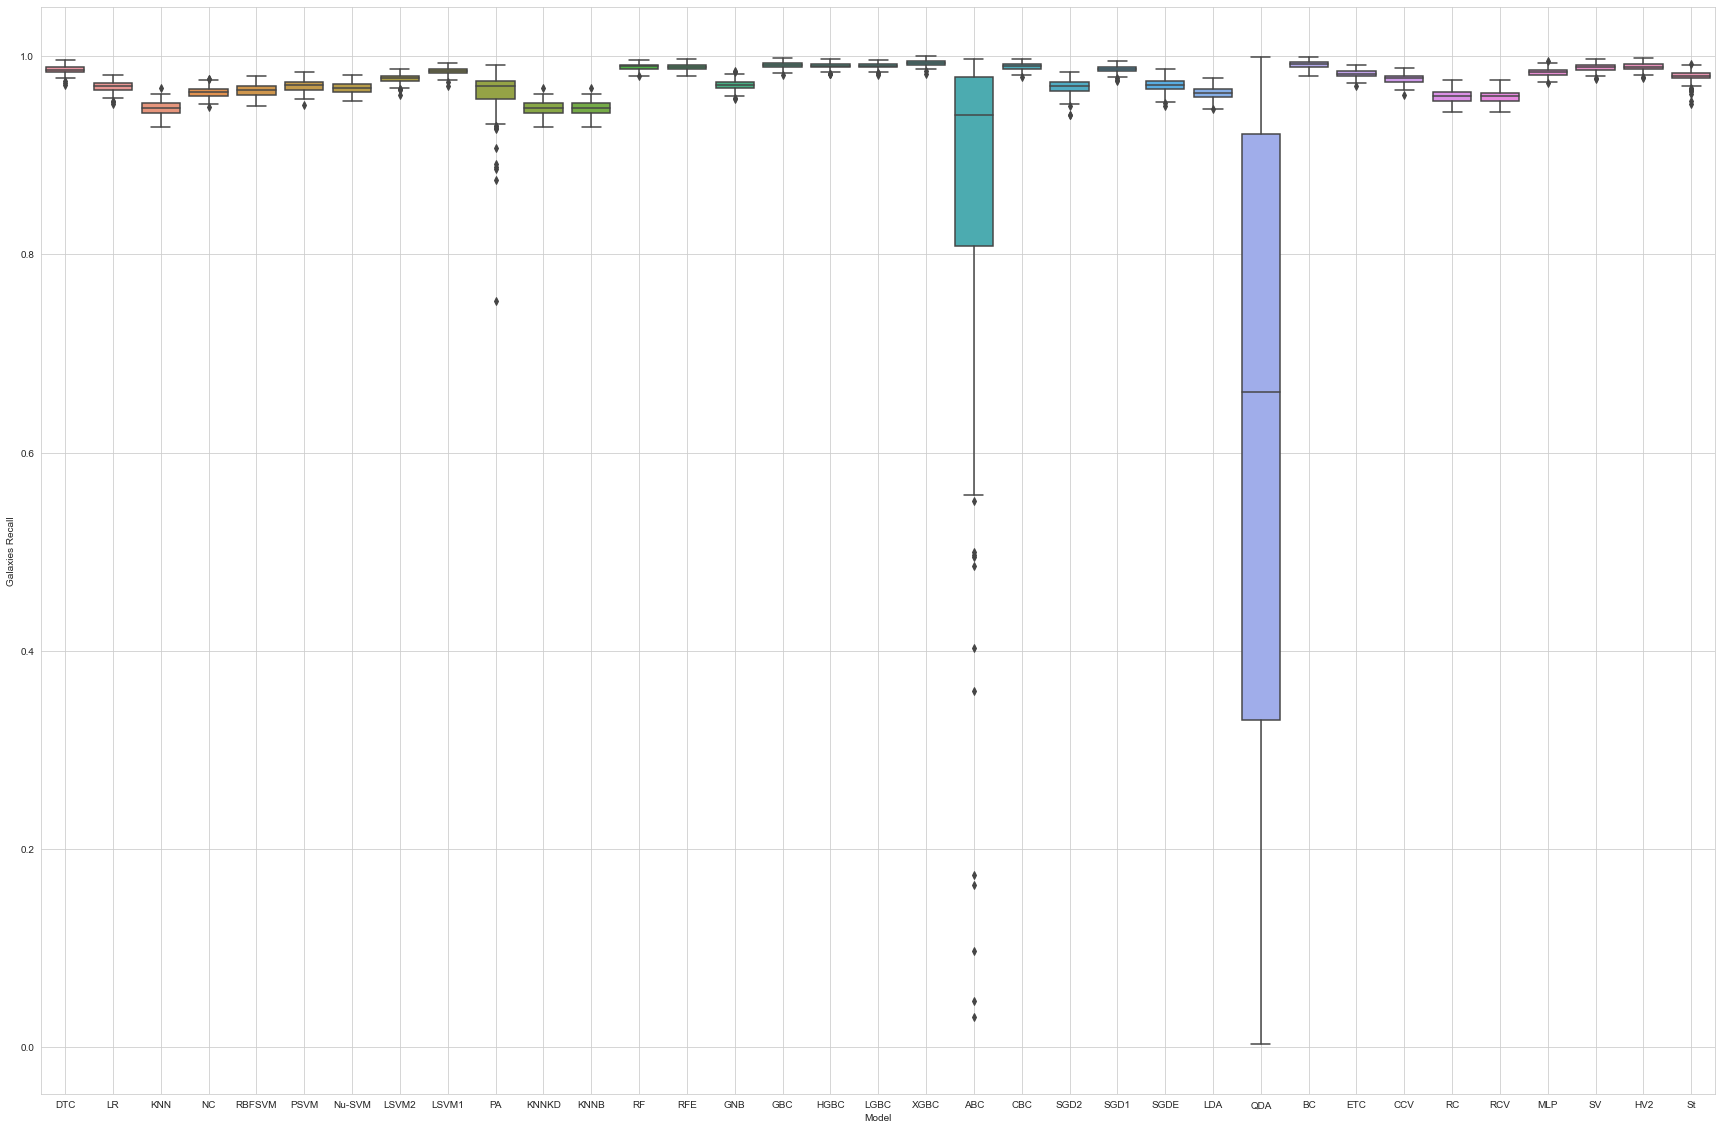

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Galaxies Recall")
plt.grid(visible=True)
plt.savefig("GRec.png")
plt.show()

### Galaxies F1-score Box-Plot:

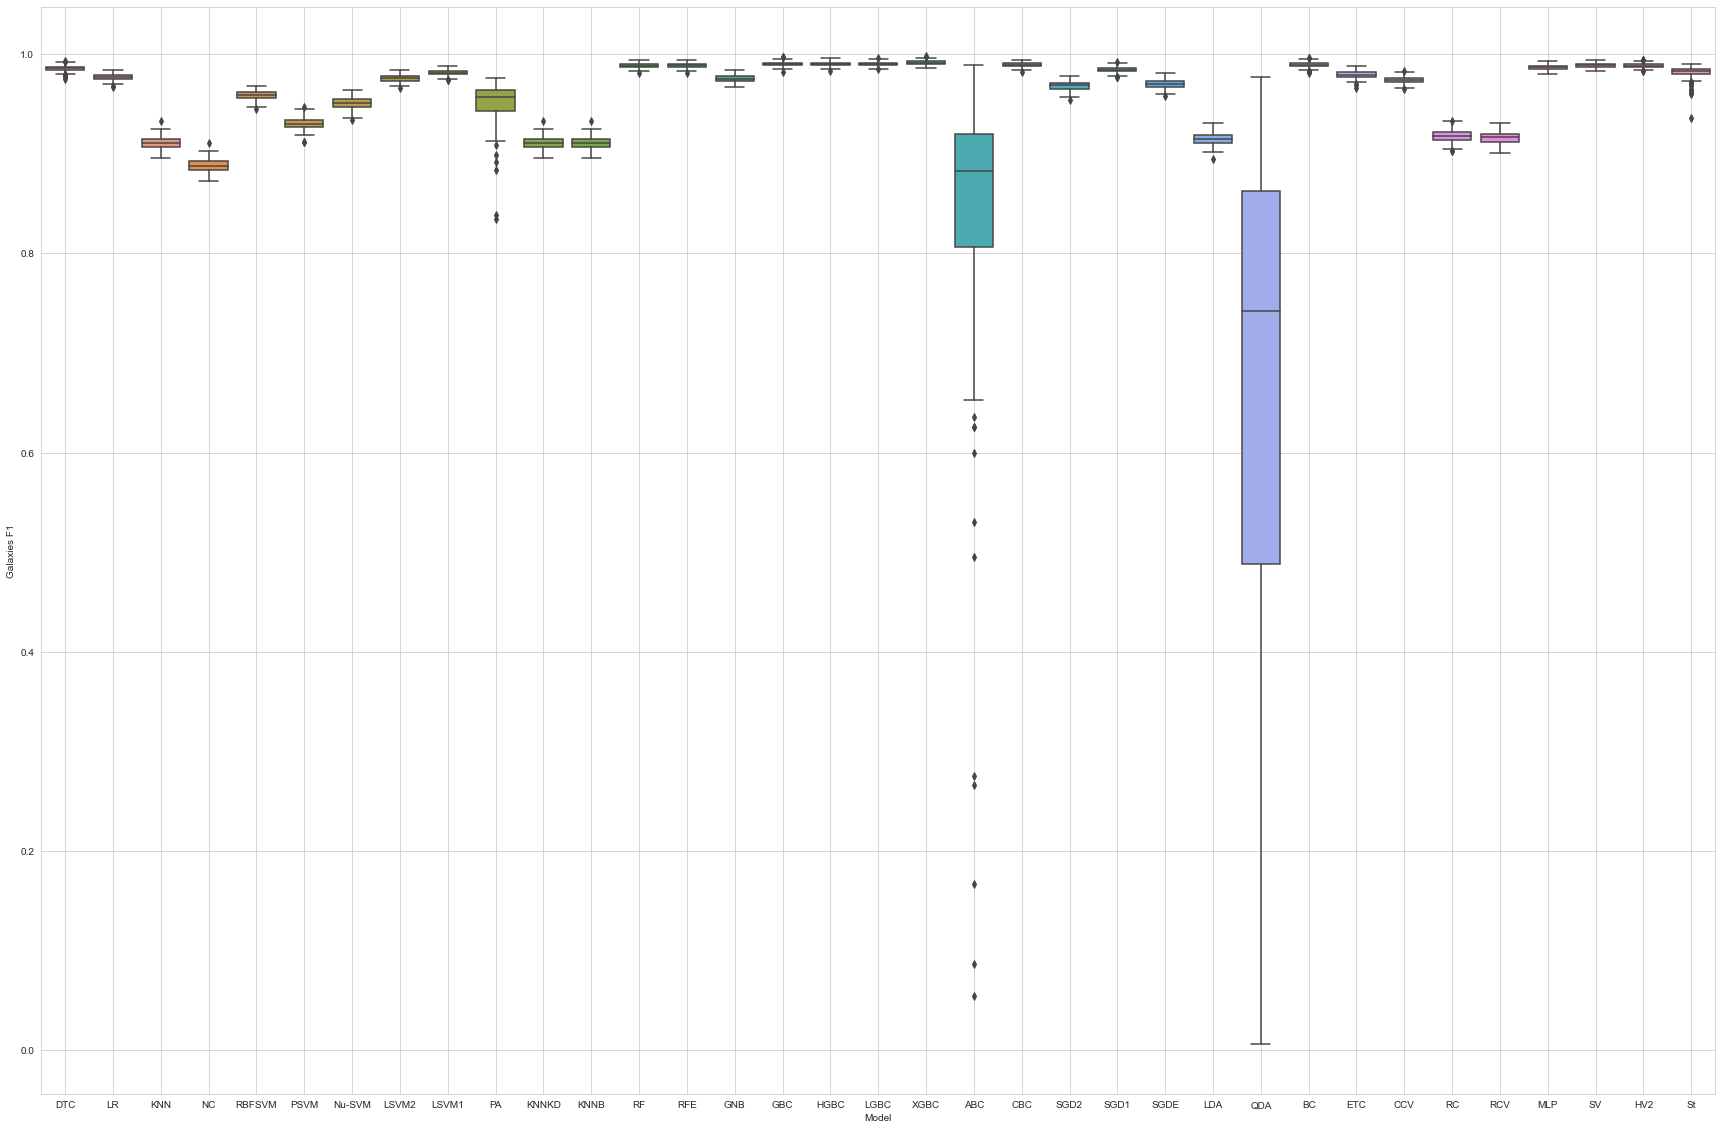

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Galaxies F1")
plt.grid(visible=True)
plt.savefig("GF.png")
plt.show()

### Quasars Precision Box-Plot:

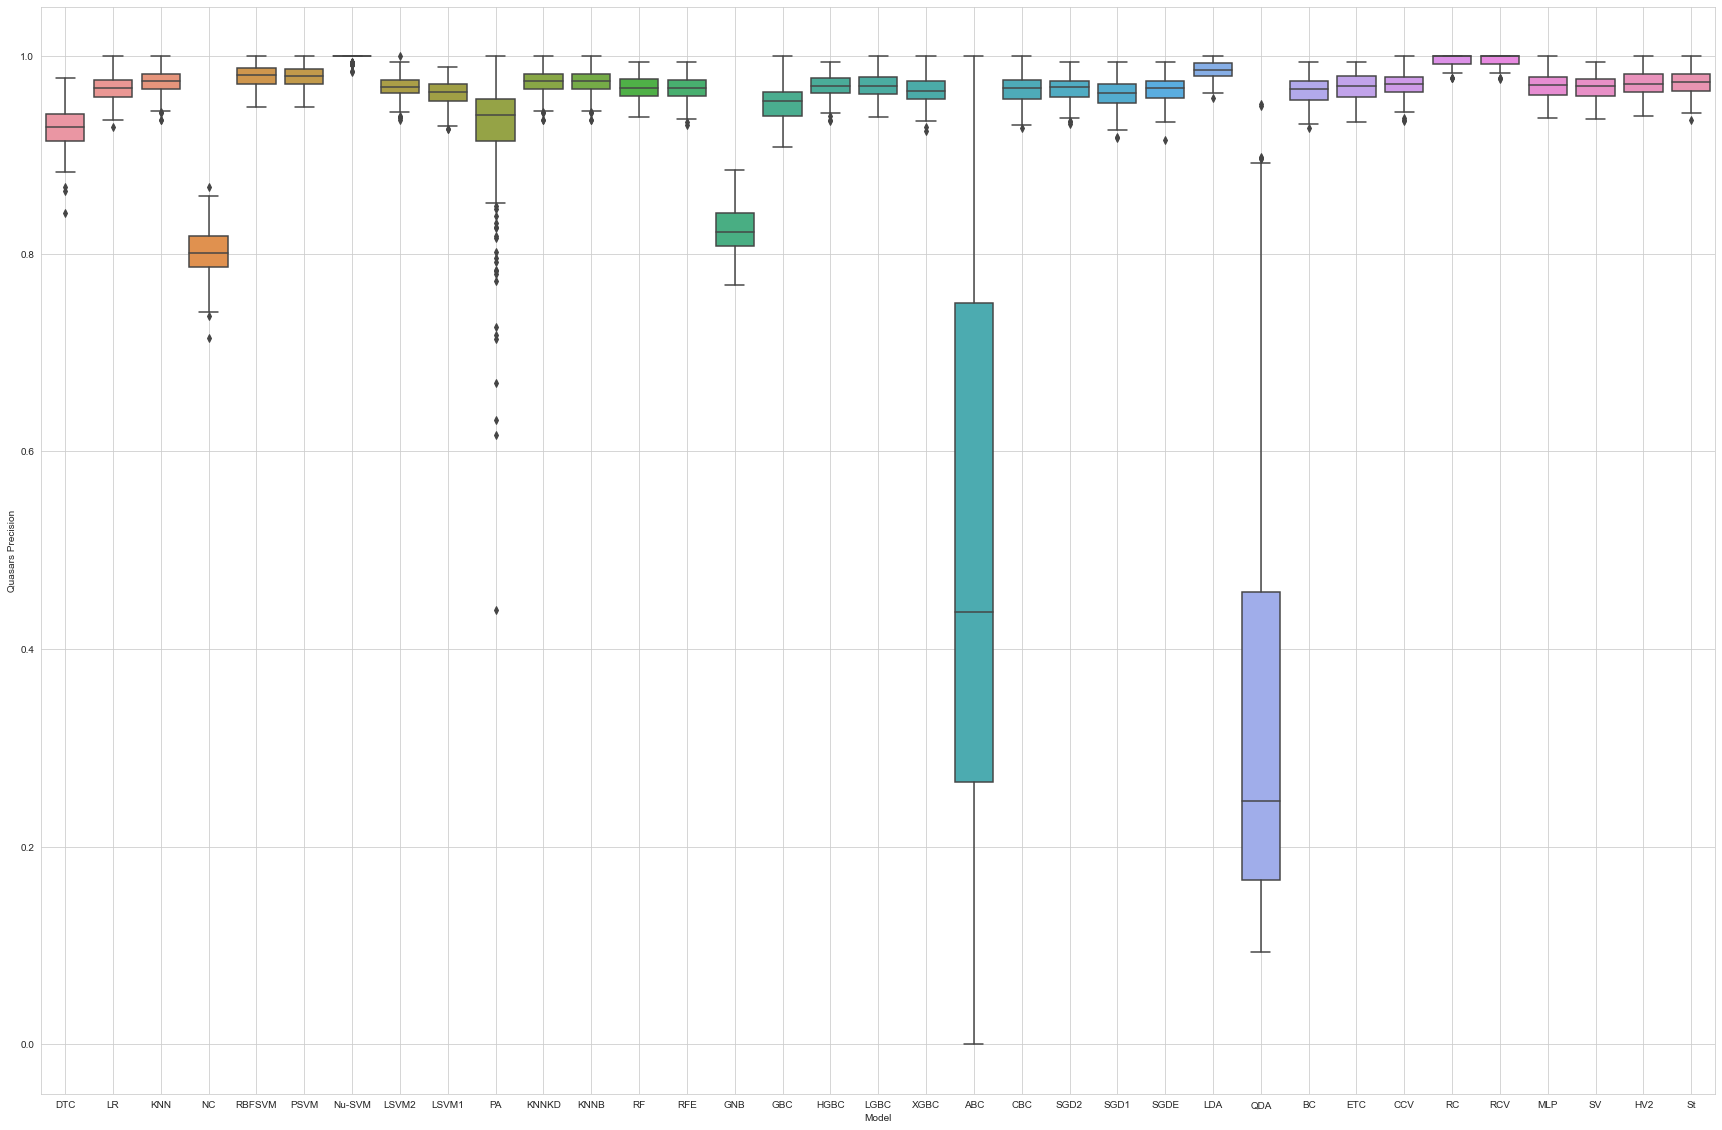

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Quasars Precision")
plt.grid(visible=True)
plt.savefig("QPrec.png")
plt.show()

### Quasars Recall Box-Plot:

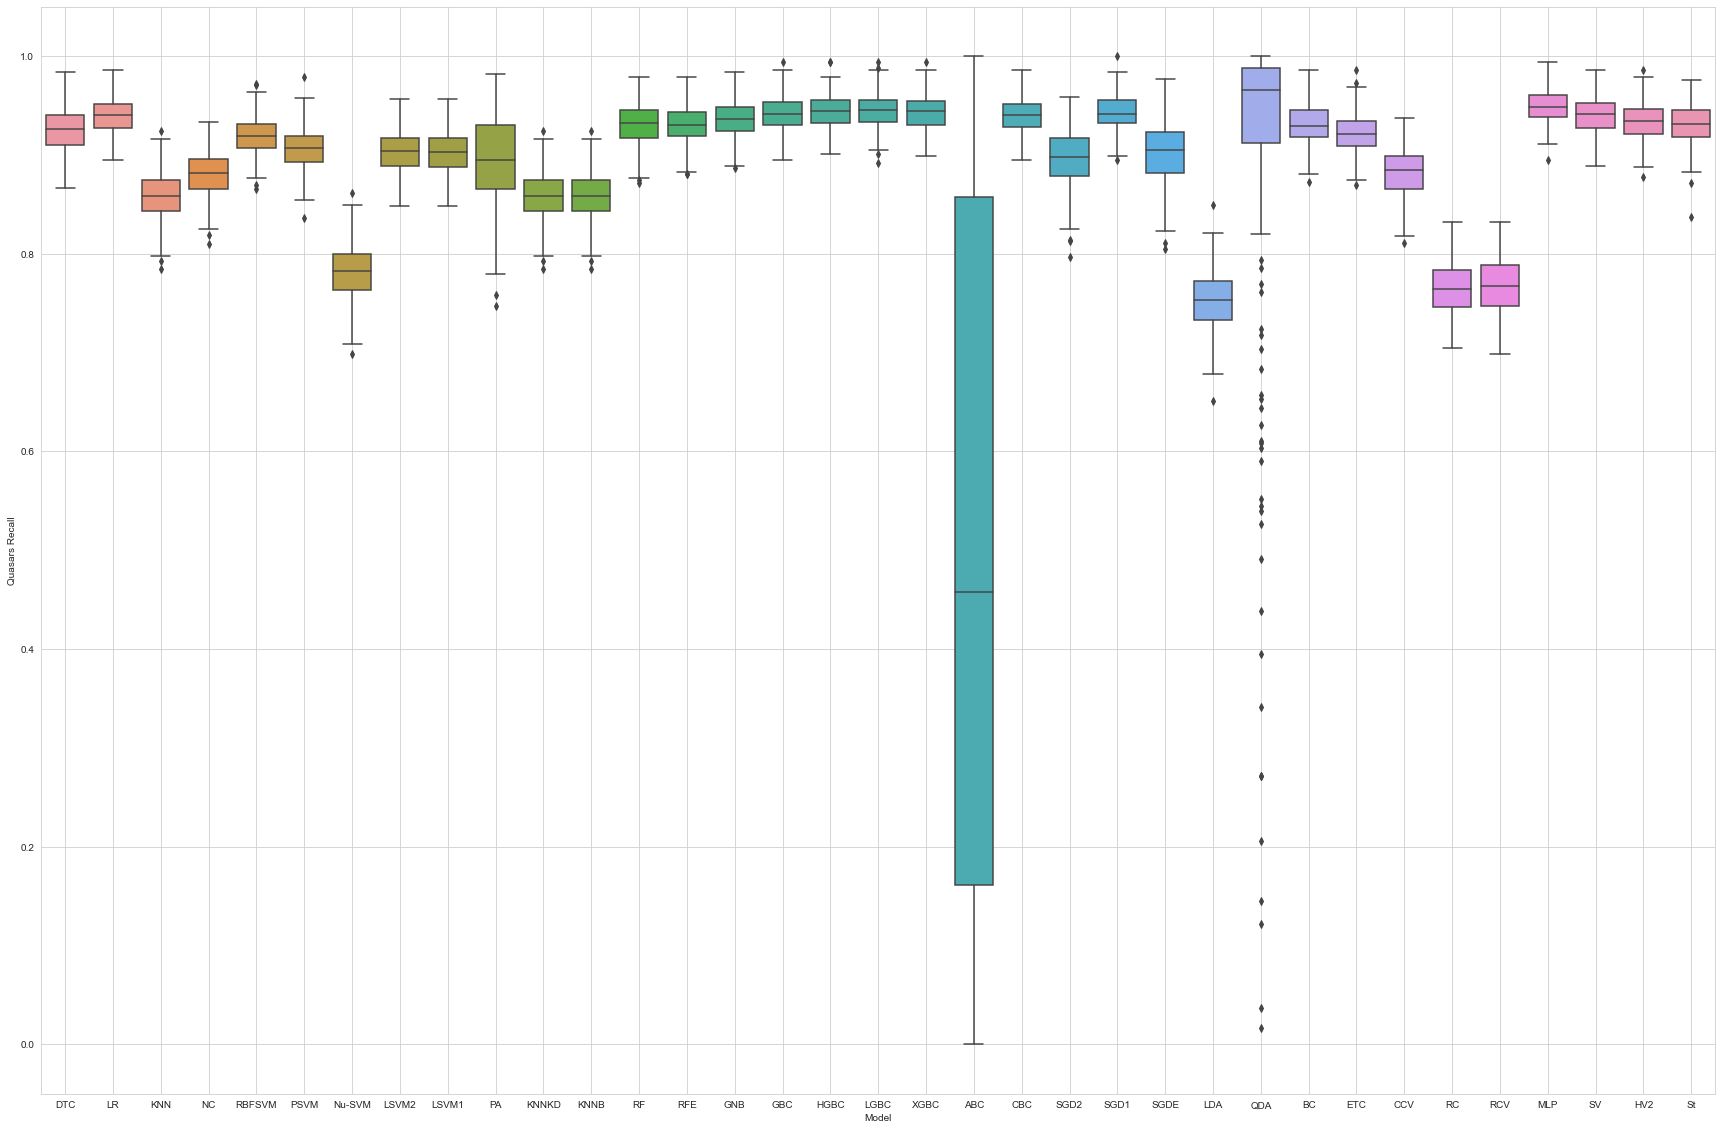

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Quasars Recall")
plt.grid(visible=True)
plt.savefig("QRec.png")
plt.show()

### Quasars F-1 score Box-Plot:

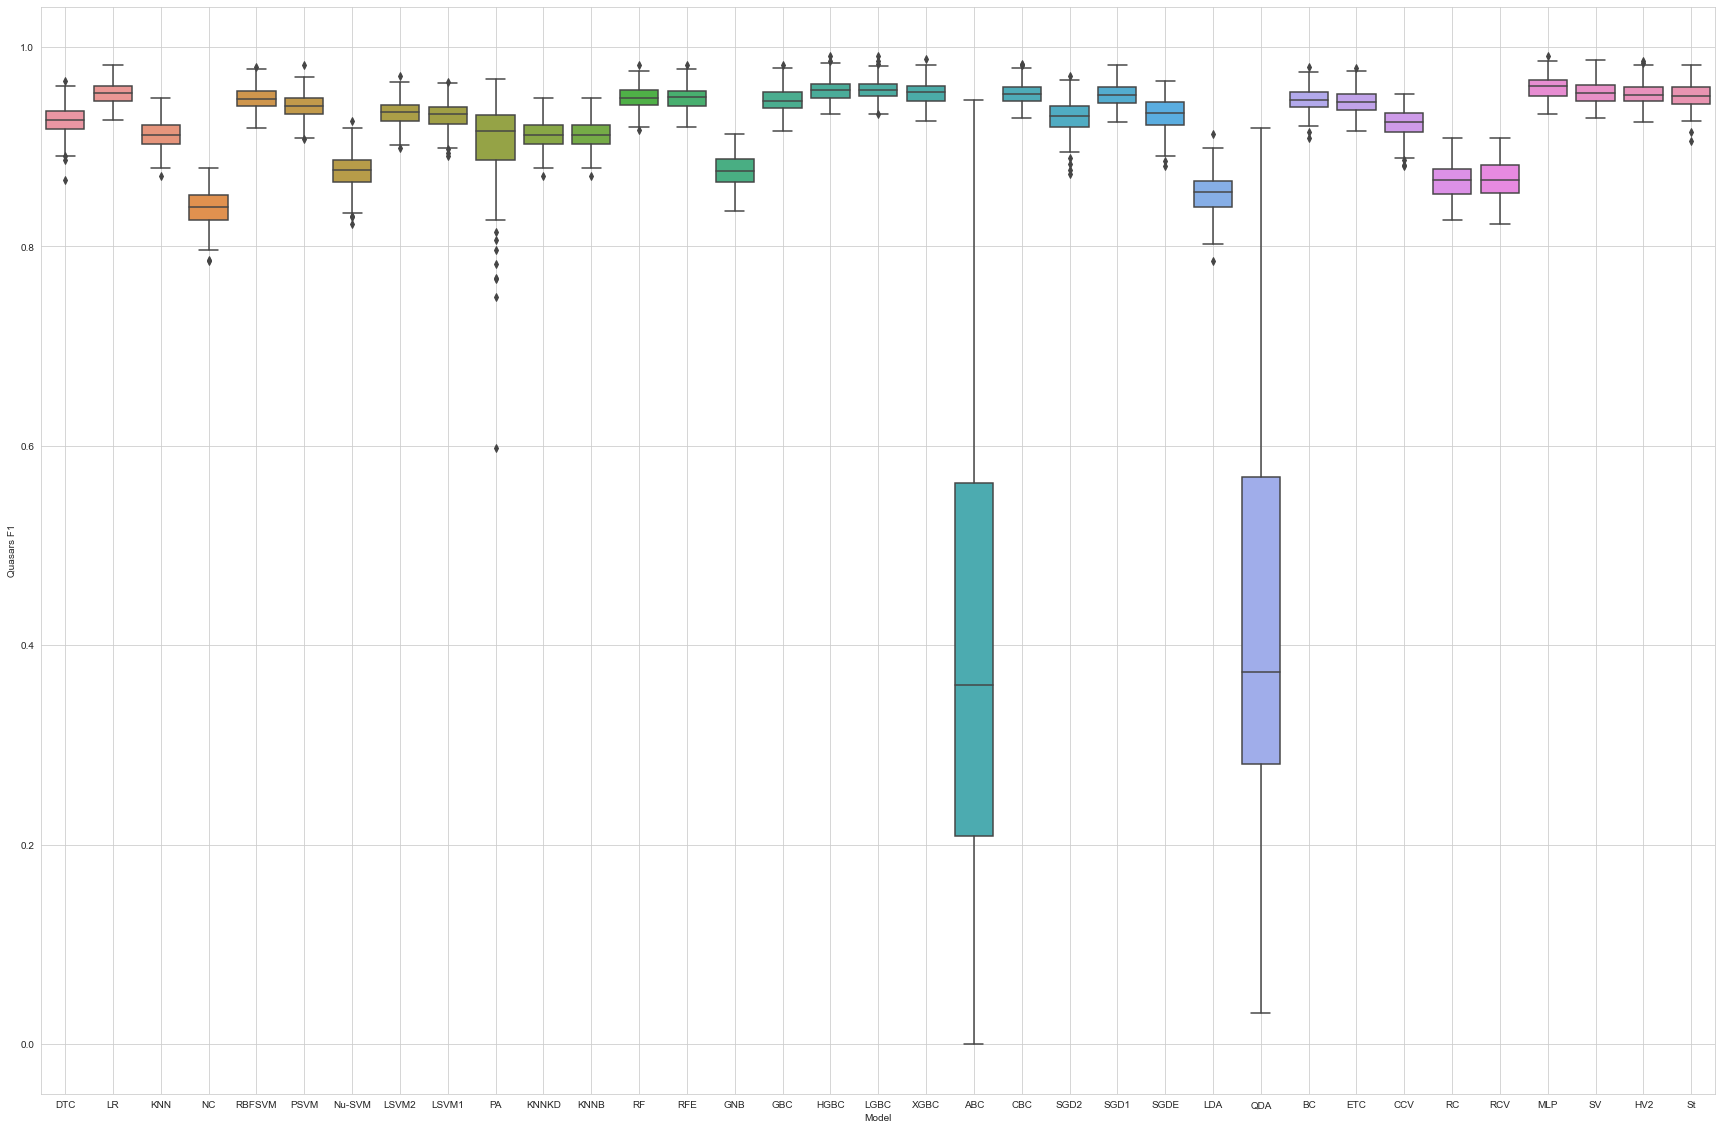

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Quasars F1")
plt.grid(visible=True)
plt.savefig("QF.png")
plt.show()

### Stars Precision Box-Plot:

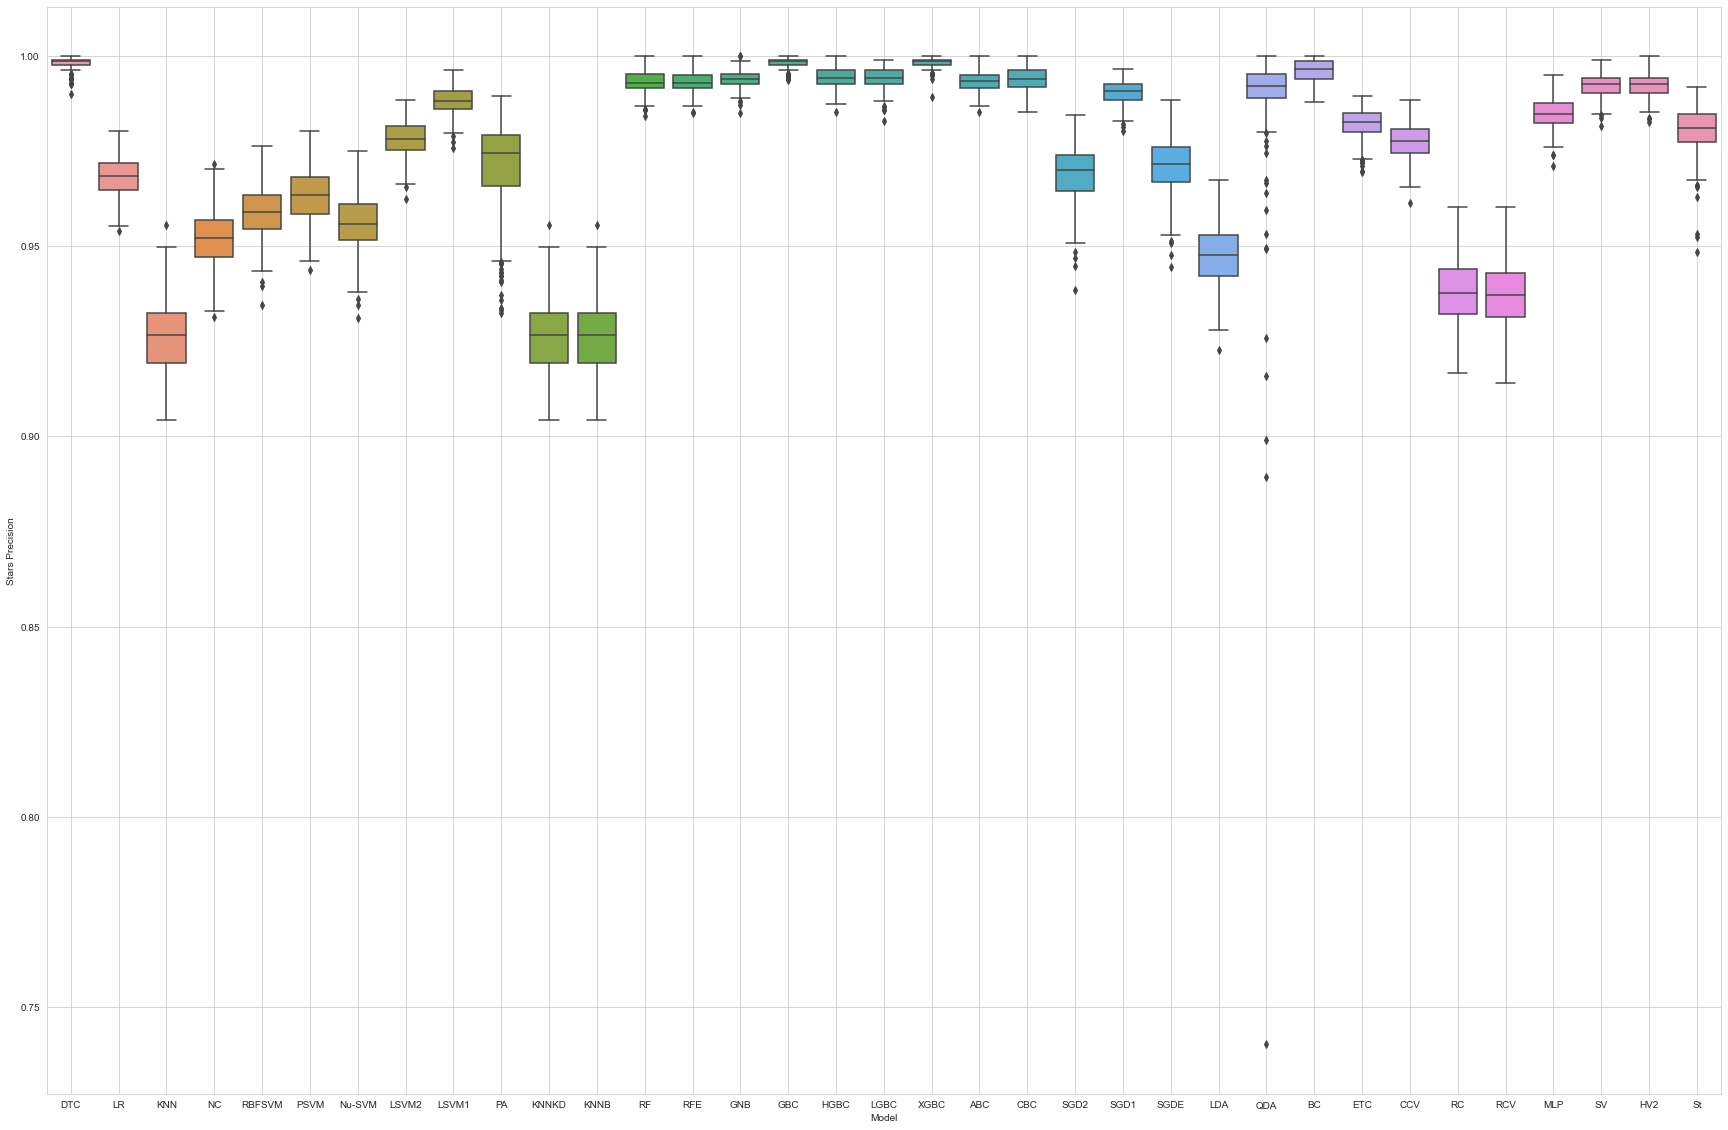

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Stars Precision")
plt.grid(visible=True)
plt.savefig("SPrec.png")
plt.show()

### Stars Recall Box-Plot

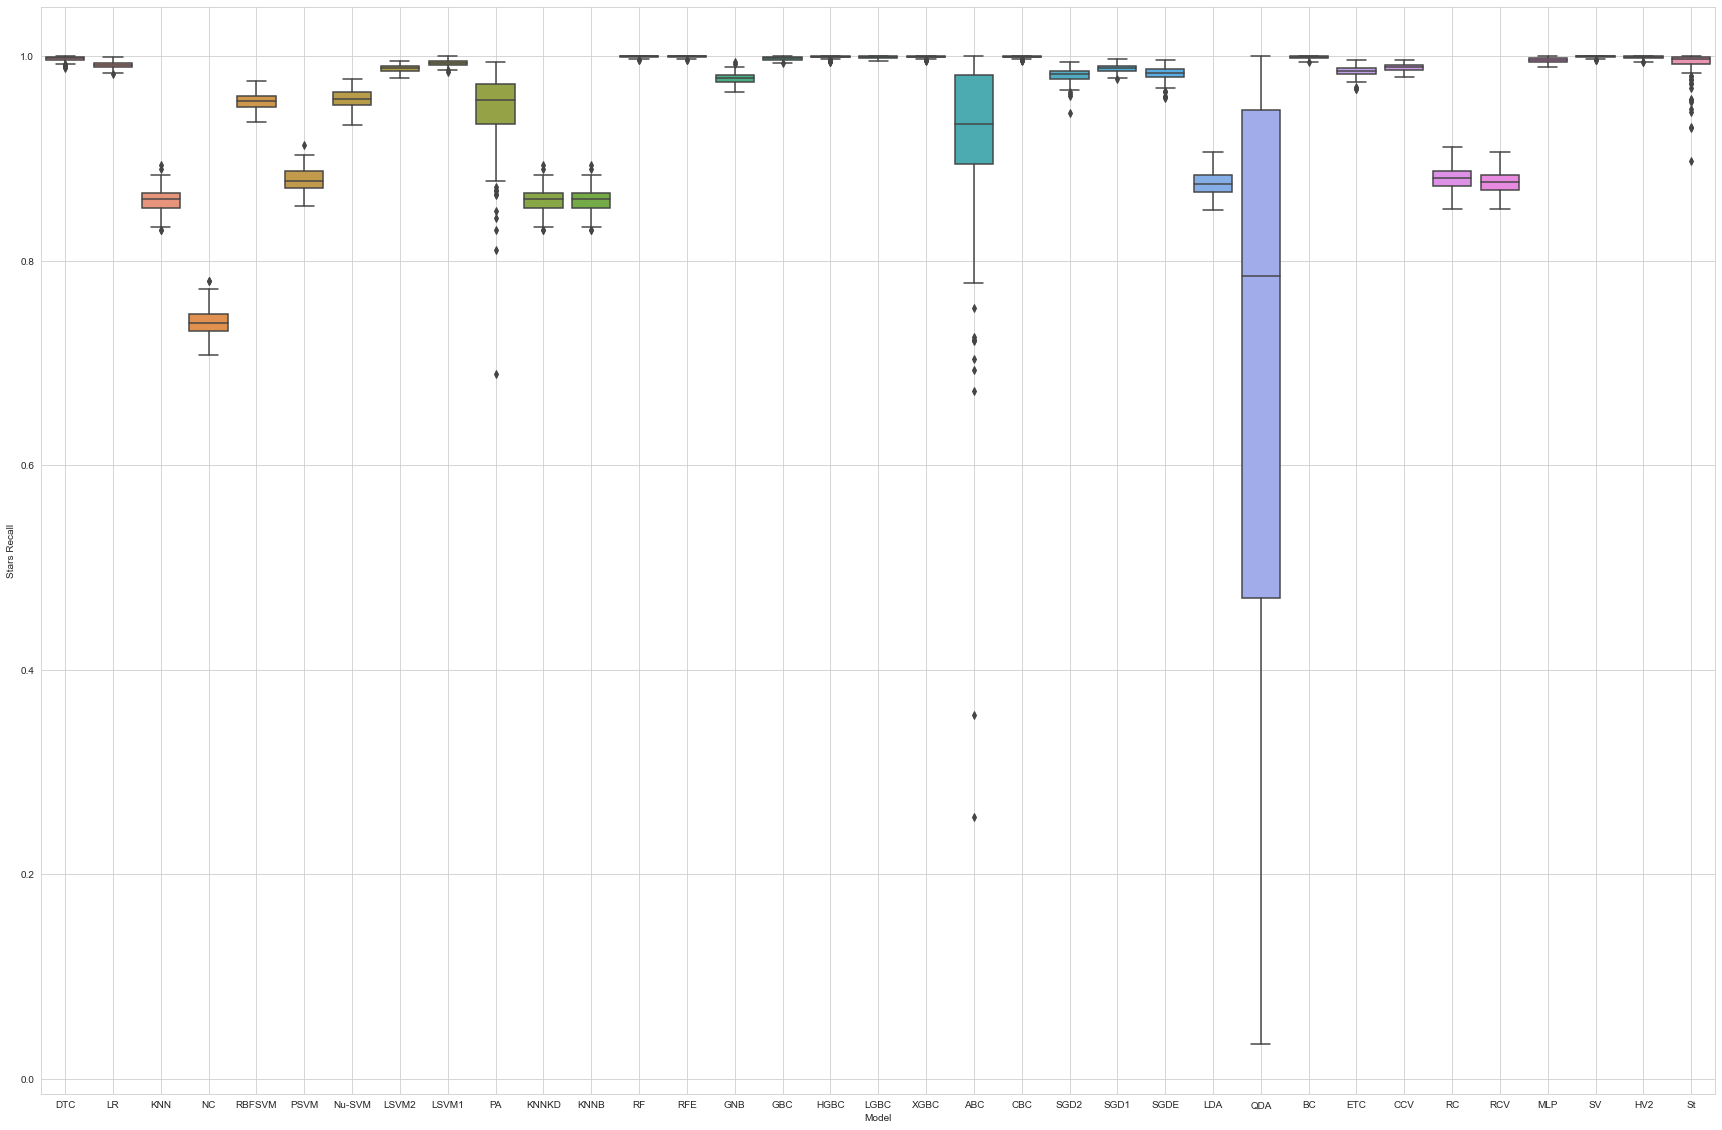

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Stars Recall")
plt.grid(visible=True)
plt.savefig("SRec.png")
plt.show()

### Stars F1-score Box-Plots:

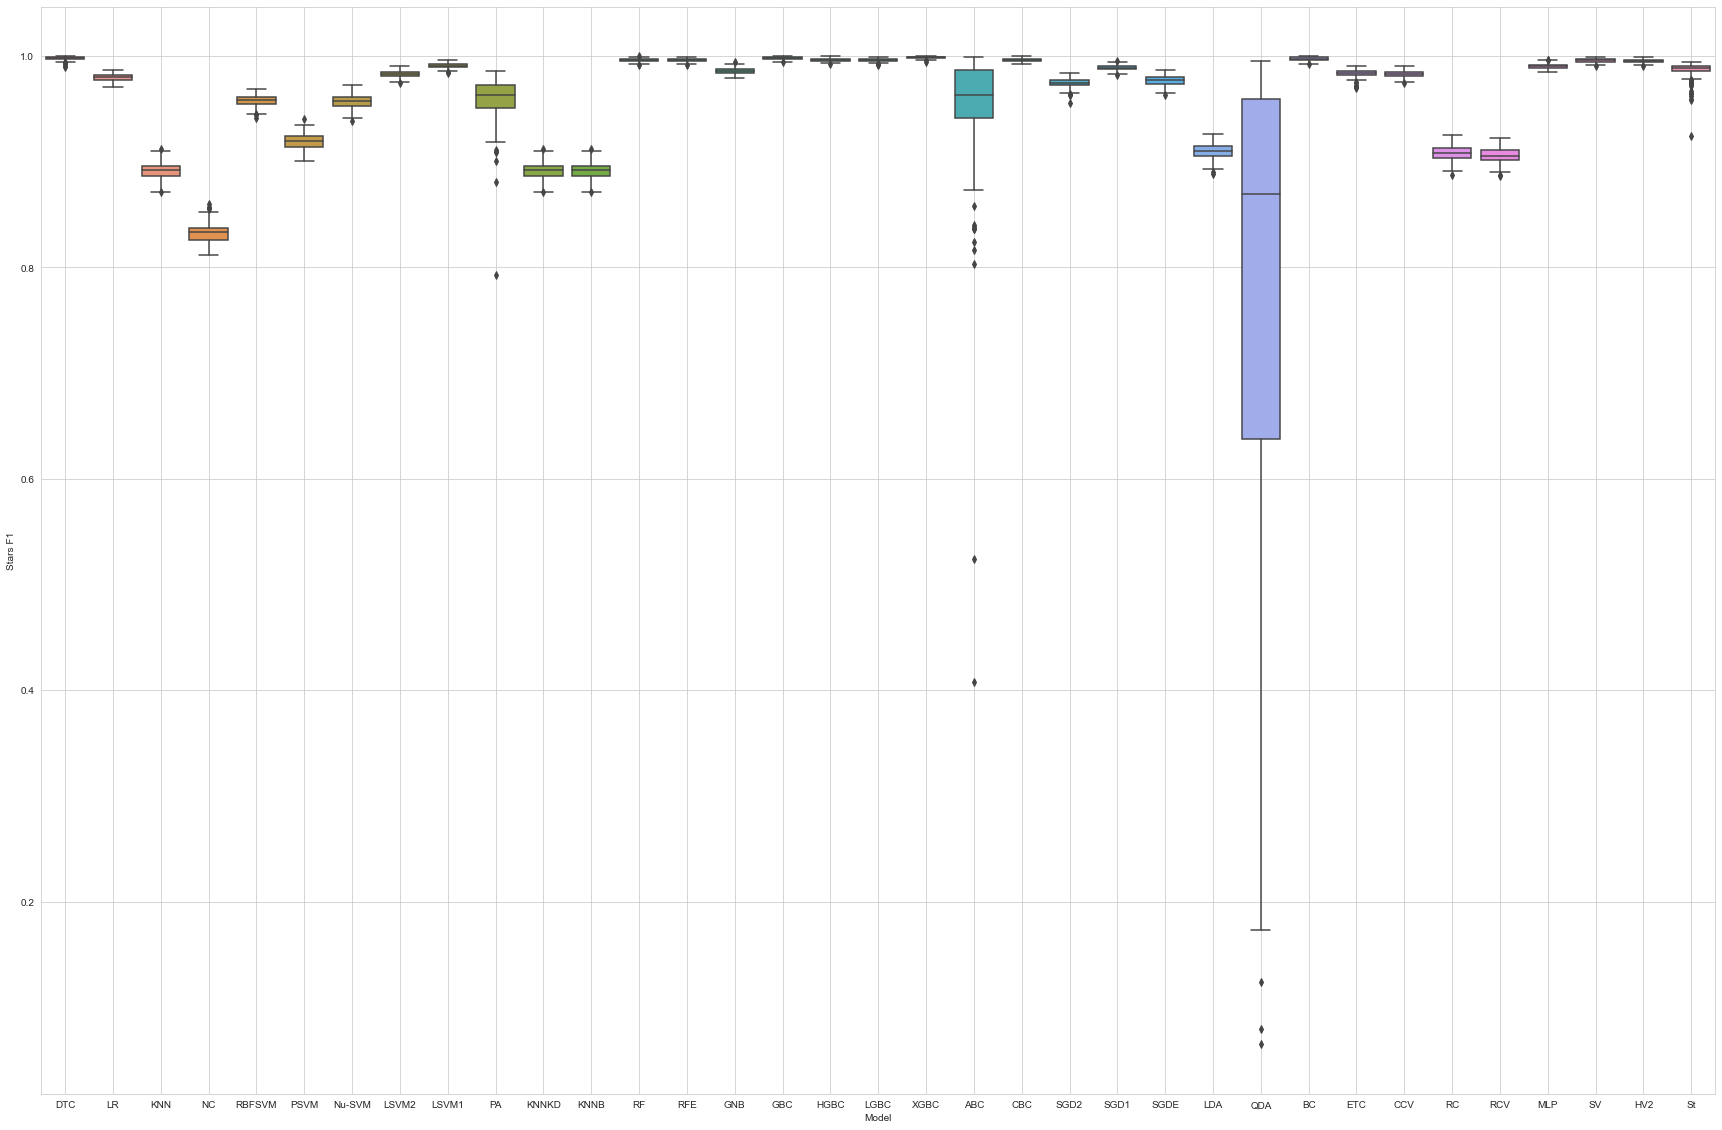

In [ ]:
plt.figure(figsize = (30, 20))
sns.set_style('whitegrid')
sns.boxplot(data = Data, x = "Model", y = "Stars F1")
plt.grid(visible=True)
plt.savefig("SF.png")
plt.show()